In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Higgs_Dataset/"

In [ ]:
!pip install networkx pandas tqdm scikit-learn

In [ ]:
import pandas as pd

reply = pd.read_csv(DATA_PATH + "higgs-reply_network.edgelist", sep=" ", header=None)
mention = pd.read_csv(DATA_PATH + "higgs-mention_network.edgelist", sep=" ", header=None)
retweet = pd.read_csv(DATA_PATH + "higgs-retweet_network.edgelist", sep=" ", header=None)

In [ ]:
reply.columns = ["user_u", "user_v", "timestamp"]
mention.columns = ["user_u", "user_v", "timestamp"]
retweet.columns = ["user_u", "user_v", "timestamp"]

In [ ]:
reply["type"] = "reply"
mention["type"] = "mention"
retweet["type"] = "retweet"

In [ ]:
df = pd.concat([reply, mention, retweet], ignore_index=True)

In [ ]:
df.head()
df.shape

(511473, 4)

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit='s')
df["date"] = df["timestamp"].dt.date

In [ ]:
df = df.dropna()
df = df[df["user_u"] != df["user_v"]]

In [ ]:
df = df.sort_values(by="timestamp")

TEMPORAL GRAPH CONSTRUCTION

In [ ]:
activity = pd.read_csv(DATA_PATH + "higgs-activity_time.txt", sep=" ", header=None)

activity.columns = ["u", "v", "t", "type"]

In [ ]:
print(activity.head())

        u       v           t type
0  223789  213163  1341100972   MT
1  223789  213163  1341100972   RE
2  376989   50329  1341101181   RT
3   26375  168366  1341101183   MT
4  376989   13813  1341101192   RT


In [ ]:
activity["t"] = pd.to_datetime(activity["t"], unit="s")
activity["date"] = activity["t"].dt.date

In [ ]:
print(activity.head())
print(activity["date"].nunique())

        u       v                   t type        date
0  223789  213163 2012-07-01 00:02:52   MT  2012-07-01
1  223789  213163 2012-07-01 00:02:52   RE  2012-07-01
2  376989   50329 2012-07-01 00:06:21   RT  2012-07-01
3   26375  168366 2012-07-01 00:06:23   MT  2012-07-01
4  376989   13813 2012-07-01 00:06:32   RT  2012-07-01
7


In [ ]:
import networkx as nx
daily_graphs = {}

for day, group in activity.groupby("date"):
    G = nx.DiGraph()

    for _, row in group.iterrows():
        G.add_edge(row["u"], row["v"])

    daily_graphs[day] = G

print("Total days:", len(daily_graphs))

Total days: 7


In [ ]:
print(list(daily_graphs.keys())[:5])

[datetime.date(2012, 7, 1), datetime.date(2012, 7, 2), datetime.date(2012, 7, 3), datetime.date(2012, 7, 4), datetime.date(2012, 7, 5)]


In [ ]:
import pickle

with open(DATA_PATH + "daily_graphs.pkl", "wb") as f:
    pickle.dump(daily_graphs, f)

print("✅ daily_graphs.pkl saved")

✅ daily_graphs.pkl saved


Feature Engineering

In [ ]:
import pickle
import pandas as pd
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Higgs_Dataset/"

with open(DATA_PATH + "daily_graphs.pkl", "rb") as f:
    daily_graphs = pickle.load(f)

print("Total days:", len(daily_graphs))

Total days: 7


In [ ]:
features_by_day = {}
prev_degree = {}

for day in sorted(daily_graphs.keys()):
    G = daily_graphs[day]

    # --- Basic centrality features ---
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())
    pagerank = nx.pagerank(G)

    rows = []

    for node in G.nodes():
        total_deg = indeg.get(node, 0) + outdeg.get(node, 0)
        old_deg = prev_degree.get(node, 0)
        degree_change = total_deg - old_deg

        rows.append({
            "node": node,
            "indegree": indeg.get(node, 0),
            "outdegree": outdeg.get(node, 0),
            "pagerank": pagerank.get(node, 0),
            "degree_change": degree_change
        })

        prev_degree[node] = total_deg

    df_feat = pd.DataFrame(rows)

    # --- Normalize features ---
    scaler = MinMaxScaler()
    df_feat[df_feat.columns[1:]] = scaler.fit_transform(df_feat[df_feat.columns[1:]])

    features_by_day[day] = df_feat

In [ ]:
with open(DATA_PATH + "features.pkl", "wb") as f:
    pickle.dump(features_by_day, f)

print("✅ features.pkl saved successfully")

✅ features.pkl saved successfully


In [ ]:
print(list(features_by_day.keys())[:5])
print(features_by_day[list(features_by_day.keys())[0]].head())

[datetime.date(2012, 7, 1), datetime.date(2012, 7, 2), datetime.date(2012, 7, 3), datetime.date(2012, 7, 4), datetime.date(2012, 7, 5)]
     node  indegree  outdegree  pagerank  degree_change
0  223789  0.002188      0.125  0.002150       0.002188
1  213163  0.004376      0.250  0.004476       0.006565
2  376989  0.000000      0.250  0.000000       0.002188
3   50329  0.010941      0.000  0.002017       0.008753
4   26375  0.004376      0.125  0.001009       0.004376


TGNN


In [ ]:
!pip install torch-geometric

In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Higgs_Dataset/"

with open(DATA_PATH + "daily_graphs.pkl", "rb") as f:
    daily_graphs = pickle.load(f)

with open(DATA_PATH + "features.pkl", "rb") as f:
    features_by_day = pickle.load(f)

dates = sorted(daily_graphs.keys())
dates = dates[:10]

In [ ]:
all_nodes = set()
for d in dates:
    all_nodes.update(daily_graphs[d].nodes())

all_nodes = sorted(list(all_nodes))
node_to_idx = {n:i for i,n in enumerate(all_nodes)}
idx_to_node = {i:n for n,i in node_to_idx.items()}

num_nodes = len(all_nodes)
input_dim = len(features_by_day[dates[0]].columns) - 1
hidden_dim = 32

print("Nodes:", num_nodes, "Input dim:", input_dim)

Nodes: 304691 Input dim: 4


In [ ]:
graph_data = []

for d in dates:
    G = daily_graphs[d]
    feat_df = features_by_day[d]

    x = torch.zeros((num_nodes, input_dim), dtype=torch.float)

    for _, row in feat_df.iterrows():
        idx = node_to_idx[row["node"]]
        x[idx] = torch.tensor(row[1:].values, dtype=torch.float)

    edges = []
    for u, v in G.edges():
        edges.append([node_to_idx[u], node_to_idx[v]])

    if len(edges) == 0:
        edge_index = torch.empty((2,0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    data = Data(x=x, edge_index=edge_index)
    graph_data.append(data)

In [ ]:
graph_data = [data.to(device) for data in graph_data]

In [ ]:
class TGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super(TGNN, self).__init__()
        self.gcn1 = GCNConv(in_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

    def forward(self, snapshots):
        embeddings = []

        for data in snapshots:
            x = data.x
            edge_index = data.edge_index

            h = self.gcn1(x, edge_index)
            h = torch.relu(h)

            h = self.gcn2(h, edge_index)
            h = torch.relu(h)

            embeddings.append(h)

        seq = torch.stack(embeddings, dim=1)   # [nodes, time, hidden]
        out, _ = self.gru(seq)

        final_emb = out[:, -1, :]
        return final_emb, out

In [ ]:
model = TGNN(input_dim, hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(30):
    model.train()
    optimizer.zero_grad()

    final_emb, seq_out = model(graph_data)

    loss = 0
    for t in range(len(graph_data)-1):
        loss += ((seq_out[:, t, :] - seq_out[:, t+1, :])**2).mean()

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0024
Epoch 2, Loss: 0.0022
Epoch 3, Loss: 0.0020
Epoch 4, Loss: 0.0018
Epoch 5, Loss: 0.0016
Epoch 6, Loss: 0.0015
Epoch 7, Loss: 0.0014
Epoch 8, Loss: 0.0013
Epoch 9, Loss: 0.0012
Epoch 10, Loss: 0.0011
Epoch 11, Loss: 0.0010
Epoch 12, Loss: 0.0009
Epoch 13, Loss: 0.0009
Epoch 14, Loss: 0.0008
Epoch 15, Loss: 0.0007
Epoch 16, Loss: 0.0007
Epoch 17, Loss: 0.0007
Epoch 18, Loss: 0.0006
Epoch 19, Loss: 0.0006
Epoch 20, Loss: 0.0005
Epoch 21, Loss: 0.0005
Epoch 22, Loss: 0.0005
Epoch 23, Loss: 0.0005
Epoch 24, Loss: 0.0004
Epoch 25, Loss: 0.0004
Epoch 26, Loss: 0.0004
Epoch 27, Loss: 0.0004
Epoch 28, Loss: 0.0003
Epoch 29, Loss: 0.0003
Epoch 30, Loss: 0.0003


In [ ]:
model.eval()
with torch.no_grad():
    final_emb, seq_out = model(graph_data)

torch.save(final_emb.cpu(), DATA_PATH + "final_embeddings.pt")
torch.save(seq_out.cpu(), DATA_PATH + "temporal_embeddings.pt")

# Save node mapping
with open(DATA_PATH + "node_mapping.pkl", "wb") as f:
    pickle.dump(node_to_idx, f)

print("✅ Embeddings saved")

✅ Embeddings saved


In [ ]:
print(final_emb.shape)
print(final_emb[0])

torch.Size([304691, 32])
tensor([-0.0435, -0.1237, -0.0066,  0.0626, -0.0531,  0.1169, -0.0963,  0.1047,
        -0.0137,  0.0277,  0.0625,  0.0336,  0.0425,  0.0021, -0.0414,  0.0571,
         0.0274,  0.0106, -0.0193,  0.0809,  0.0073, -0.0005,  0.1101, -0.0285,
         0.0252, -0.0433, -0.0862,  0.0471, -0.0299,  0.0994,  0.0309, -0.0696])


Hybrid Influence Score

In [ ]:
import torch
import pickle
import numpy as np

DATA_PATH = "/content/drive/MyDrive/Higgs_Dataset/"

# TGNN outputs
final_emb = torch.load(DATA_PATH + "final_embeddings.pt")
temporal_emb = torch.load(DATA_PATH + "temporal_embeddings.pt")

# Features + mapping
with open(DATA_PATH + "features.pkl", "rb") as f:
    features_by_day = pickle.load(f)

with open(DATA_PATH + "node_mapping.pkl", "rb") as f:
    node_to_idx = pickle.load(f)

idx_to_node = {i:n for n,i in node_to_idx.items()}

In [ ]:
def compute_static_score(row):
    return (
        0.4 * row["indegree"] +
        0.3 * row["outdegree"] +
        0.3 * row["pagerank"]
    )

In [ ]:
dynamic_scores = final_emb.norm(dim=1).numpy()

In [ ]:
lambda_val = 0.5

hybrid_scores = {}

# Use LAST day features
last_day = sorted(features_by_day.keys())[-1]
df_feat = features_by_day[last_day]

for _, row in df_feat.iterrows():
    node = row["node"]
    idx = node_to_idx[node]

    static_score = compute_static_score(row)
    dynamic_score = dynamic_scores[idx]

    hybrid_score = lambda_val * static_score + (1 - lambda_val) * dynamic_score

    hybrid_scores[node] = hybrid_score

In [ ]:
top_nodes = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Influential Nodes:")
for node, score in top_nodes:
    print(node, score)

Top Influential Nodes:
88.0 0.6418303085601627
2164.0 0.5522874030627702
31240.0 0.41041485379465725
71.0 0.40830858041227736
9964.0 0.4013966405680878
181190.0 0.3924924820661545
677.0 0.36968686842850546
6948.0 0.3503406481124125
103447.0 0.3485058452150037
2014.0 0.33306105108774786


In [ ]:
lambda_val = 0.5

all_hybrid_scores = {}

dates = sorted(features_by_day.keys())

for t_idx, day in enumerate(dates):
    df_feat = features_by_day[day]

    day_scores = {}

    for _, row in df_feat.iterrows():
        node = row["node"]
        idx = node_to_idx[node]

        # Static score
        static_score = (
            0.4 * row["indegree"] +
            0.3 * row["outdegree"] +
            0.3 * row["pagerank"]
        )

        # Dynamic score (use temporal embedding at time t)
        dynamic_score = temporal_emb[idx, t_idx].norm().item()

        hybrid_score = lambda_val * static_score + (1 - lambda_val) * dynamic_score

        day_scores[node] = hybrid_score

    all_hybrid_scores[day] = day_scores

In [ ]:
shift_results = {}

threshold = 0.01  # you can tune this

for i in range(1, len(dates)):
    prev_day = dates[i-1]
    curr_day = dates[i]

    shift_results[curr_day] = {}

    for node in all_hybrid_scores[curr_day]:
        prev_score = all_hybrid_scores[prev_day].get(node, 0)
        curr_score = all_hybrid_scores[curr_day][node]

        delta = curr_score - prev_score

        if delta > threshold:
            label = "Rising"
        elif delta < -threshold:
            label = "Falling"
        else:
            label = "Stable"

        shift_results[curr_day][node] = {
            "delta": delta,
            "label": label
        }

In [ ]:
sample_day = dates[-1]

for i, (node, info) in enumerate(shift_results[sample_day].items()):
    print(node, info)
    if i > 10:
        break

189727.0 {'delta': np.float64(0.18197750778574692), 'label': 'Rising'}
3533.0 {'delta': np.float64(0.0015706819557999296), 'label': 'Stable'}
22367.0 {'delta': np.float64(0.1831242694662921), 'label': 'Rising'}
71.0 {'delta': np.float64(0.15790004612687436), 'label': 'Rising'}
5449.0 {'delta': np.float64(0.1832680964154406), 'label': 'Rising'}
17109.0 {'delta': np.float64(-0.013049287589312009), 'label': 'Falling'}
89805.0 {'delta': np.float64(-0.004435456332583854), 'label': 'Stable'}
3972.0 {'delta': np.float64(0.03453002425747814), 'label': 'Rising'}
8889.0 {'delta': np.float64(0.002213990604668342), 'label': 'Stable'}
9038.0 {'delta': np.float64(0.17545292066337173), 'label': 'Rising'}
25850.0 {'delta': np.float64(0.0014824274888938782), 'label': 'Stable'}
2014.0 {'delta': np.float64(-0.018845527528364547), 'label': 'Falling'}


In [ ]:
day = dates[-1]

rising_nodes = [
    (node, data["delta"])
    for node, data in shift_results[day].items()
    if data["label"] == "Rising"
]

top_rising = sorted(rising_nodes, key=lambda x: x[1], reverse=True)[:10]

print("Top Rising Influencers:")
for node, val in top_rising:
    print(node, val)

Top Rising Influencers:
2164.0 0.3805518018937345
288604.0 0.25524706025325405
103247.0 0.25485577524450065
233720.0 0.24899106574685947
31240.0 0.24093436381198793
132575.0 0.23910350721133383
10879.0 0.23854350667250784
6753.0 0.23530937511052236
10880.0 0.23105928540989468
37105.0 0.2298142592916262


PREDICTION MODULE


In [ ]:
node_time_series = {}

for day in dates:
    for node, score in all_hybrid_scores[day].items():
        if node not in node_time_series:
            node_time_series[node] = []
        node_time_series[node].append(score)

In [ ]:
node = list(node_time_series.keys())[0]
print(node_time_series[node])

[np.float64(0.1256039796766345), np.float64(0.17545220290913302), np.float64(0.17481597116807612), np.float64(0.17339948187719556)]


In [ ]:
predictions = {}

for node, series in node_time_series.items():
    if len(series) >= 2:
        s_t = series[-1]
        s_prev = series[-2]

        predicted = s_t + (s_t - s_prev)

        predictions[node] = predicted

In [ ]:
future_shift = {}

threshold = 0.01

last_day = dates[-1]

for node in predictions:
    current = all_hybrid_scores[last_day].get(node, 0)
    predicted = predictions[node]

    delta = predicted - current

    if delta > threshold:
        label = "Will Rise"
    elif delta < -threshold:
        label = "Will Fall"
    else:
        label = "Stable"

    future_shift[node] = {
        "predicted_score": predicted,
        "delta": delta,
        "label": label
    }

In [ ]:
future_rising = [
    (node, data["delta"])
    for node, data in future_shift.items()
    if data["label"] == "Will Rise"
]

top_future = sorted(future_rising, key=lambda x: x[1], reverse=True)[:10]

print("🔮 Future Rising Influencers:")
for node, val in top_future:
    print(node, val)

🔮 Future Rising Influencers:
59905.0 0.42667301004979663
2164.0 0.3805518018937345
269152.0 0.3273394276801279
74014.0 0.3131919099113711
13854.0 0.3098945448070526
69127.0 0.29309099059558724
99783.0 0.2809867945599932
416134.0 0.2795466344958569
9352.0 0.2742558429429308
17332.0 0.2732186640240569


visualization

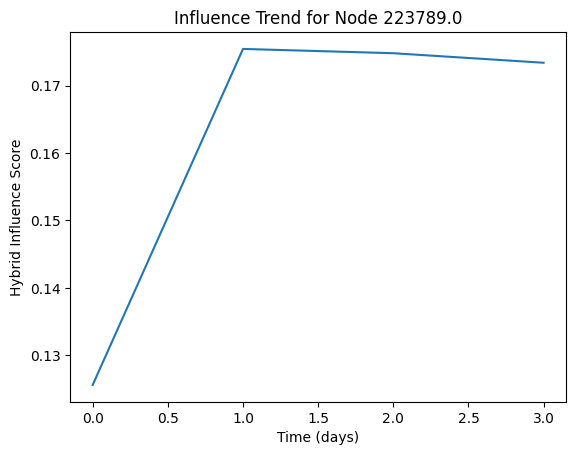

In [ ]:
import matplotlib.pyplot as plt

# pick a node
node = list(node_time_series.keys())[0]

plt.plot(node_time_series[node])
plt.title(f"Influence Trend for Node {node}")
plt.xlabel("Time (days)")
plt.ylabel("Hybrid Influence Score")
plt.show()

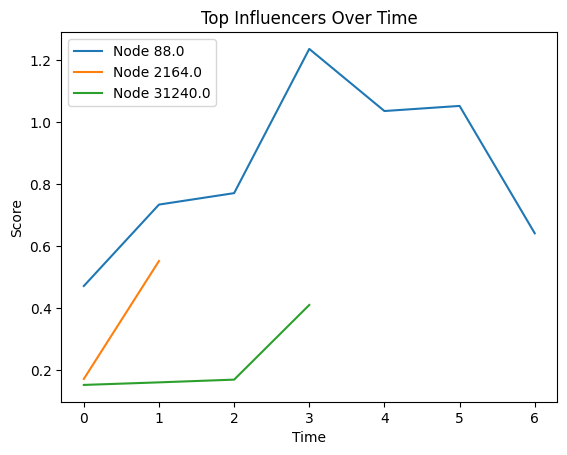

In [ ]:
top_nodes = [node for node, _ in top_nodes]  # from earlier top influencers

for node in top_nodes[:3]:
    plt.plot(node_time_series[node], label=f"Node {node}")

plt.legend()
plt.title("Top Influencers Over Time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.show()

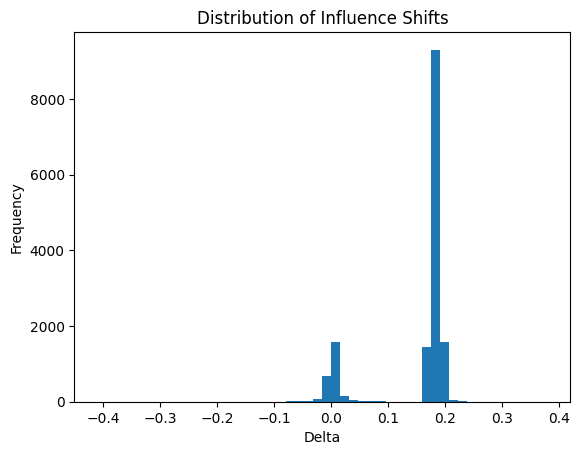

In [ ]:
deltas = []

day = dates[-1]

for node, data in shift_results[day].items():
    deltas.append(float(data["delta"]))

plt.hist(deltas, bins=50)
plt.title("Distribution of Influence Shifts")
plt.xlabel("Delta")
plt.ylabel("Frequency")
plt.show()

In [ ]:
counts = {"Rising": 0, "Falling": 0, "Stable": 0}

for node, data in shift_results[dates[-1]].items():
    counts[data["label"]] += 1

print(counts)

{'Rising': 12854, 'Falling': 179, 'Stable': 1972}


DASHBOARD


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/Higgs_Dataset/features.pkl")
files.download("/content/drive/MyDrive/Higgs_Dataset/daily_graphs.pkl")
files.download("/content/drive/MyDrive/Higgs_Dataset/temporal_embeddings.pt")
files.download("/content/drive/MyDrive/Higgs_Dataset/final_embeddings.pt")
files.download("/content/drive/MyDrive/Higgs_Dataset/node_mapping.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>